[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/1_MulticlassClassification_Iris_structured_data.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 14 (M2.3) - Iris: from two classes to three (softmax)

- Multiclass is a small step: output nodes = number of classes, activation = softmax, loss = categorical_crossentropy. That's the whole diff.
- TRAP: Iris is sorted alphabetically by class - shuffle (frac=1) + reset_index or your validation split sees ONE class. Great 60-second war story.
- Why 3 output nodes: we want a probability PER class. Softmax splits a probability mass of 1 across them; prediction = argmax, no 0.5 threshold.
- Dummy-encode y (3 columns) to match the 3 outputs.
-->

# Dense Neural Networks: Multiclass Classification
----------------------------------
**Dr. Dave Wanik**

Let's try to fit a dense neural network with the Iris dataset.

In [1]:
# for reading data
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

!pip install scikeras
from scikeras.wrappers import KerasClassifier # updated 2023

# from keras.utils import np_utils
from keras.utils import to_categorical

# for modeling
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

# useful link: https://shrikar.com/deep-learning-with-keras-and-python-for-multiclass-classification/
# useful link: https://machinelearningmastery.com/multi-class-classification-tutorial-keras-deep-learning-library/


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\dww05002\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# # read in the data
# url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/639388c2cbc2120a14dcf466e85730eb8be498bb/iris.csv'
# df = pd.read_csv(url)
# df.info()

In [3]:
# # read from shareable link
# # https://drive.google.com/file/d/1hcnnt2HJ6Iiv6yJJrk0thlPSibu_1q3x/view?usp=sharing
# !gdown 1hcnnt2HJ6Iiv6yJJrk0thlPSibu_1q3x
# df = pd.read_csv('../data/Iris.csv')

In [4]:
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module2_Files/data/Iris.csv"

# retrieve the data and build a dataframe
df = pd.read_csv(url)

df.shape

(150, 5)

In [5]:
# show the head
df.head()

,sepal length,sepal width,petal length,petal width,iris
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# show counts per species
df['iris'].value_counts()

iris
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
# don't forget to shuffle! this way our data has some order...
df = df.sample(frac=1).reset_index(drop=True)
df.head()
# link: https://stackoverflow.com/questions/29576430/shuffle-dataframe-rows

,sepal length,sepal width,petal length,petal width,iris
0,6.3,3.3,6.0,2.5,Iris-virginica
1,6.1,2.6,5.6,1.4,Iris-virginica
2,7.2,3.0,5.8,1.6,Iris-virginica
3,6.4,3.2,4.5,1.5,Iris-versicolor
4,5.0,3.4,1.6,0.4,Iris-setosa


In [8]:
# split into X and Y
Y = df['iris']
X = df.drop(['iris'], axis=1)

print(X.shape)
print(Y.shape)

(150, 4)
(150,)


In [9]:
# convert to numpy arrays
X = np.array(X)

In [10]:
# show Y
Y.head()

0     Iris-virginica
1     Iris-virginica
2     Iris-virginica
3    Iris-versicolor
4        Iris-setosa
Name: iris, dtype: str

In [11]:
# work with labels
# encode class values as integers
encoder = LabelEncoder()
encoded_Y = encoder.fit_transform(Y)
# convert integers to dummy variables (i.e. one hot encoded)
dummy_y = to_categorical(encoded_Y)

In [12]:
encoded_Y

array([2, 2, 2, 1, 0, 0, 0, 1, 0, 0, 2, 1, 0, 2, 0, 0, 2, 0, 2, 1, 1, 0,
       1, 0, 0, 0, 2, 1, 0, 0, 2, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       2, 2, 2, 0, 0, 2, 1, 0, 2, 2, 0, 2, 0, 1, 1, 1, 2, 1, 2, 2, 2, 1,
       1, 2, 2, 0, 1, 2, 0, 1, 2, 2, 0, 0, 0, 1, 1, 2, 0, 2, 0, 2, 1, 2,
       0, 1, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 0, 1, 1, 1, 2, 1, 2,
       2, 0, 0, 0, 2, 0, 1, 1, 0, 2, 0, 1, 0, 2, 2, 2, 0, 0, 2, 0, 1, 1,
       2, 2, 2, 2, 1, 0, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 0, 0])

In [13]:
print(dummy_y.shape)
dummy_y

(150, 3)


array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0

## Train/Test Split - the honest yardstick

If we train on ALL the data and then grade the model on that same data, we graded it on questions it already saw. So BEFORE we build anything: lock 30% of the rows in a vault. The model never trains on them - they exist only to answer one question at the end... *does this thing generalize?*

In [14]:
# hold out a REAL test set - 30% goes in the vault
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, dummy_y,
                                                    test_size=0.3,
                                                    random_state=123)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(105, 4) (105, 3)
(45, 4) (45, 3)


In [15]:
# build a model
model = Sequential()
model.add(Dense(16, input_shape=(X.shape[1],), activation='relu')) # input shape is (features,)
model.add(Dense(3, activation='softmax')) # output
model.summary()

# make sure in a multiclass problem that you have one output node per target class
# and use a 'softmax' activation function which forces your model to split
# it's prediction among 3 classes (all adds up to 1)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# compile the model
model.compile(optimizer='rmsprop', # use rmsprop or Adam
              loss='categorical_crossentropy', # this is different instead of binary_crossentropy (for regular classification)
              metrics=['accuracy'])

In [17]:
# fit the model - on the TRAINING partition only!
history = model.fit(X_train,
                    y_train,
                    epochs=40,
                    batch_size=10,
                    validation_split=0.2, # last 20% of the TRAINING data used as validation
                    shuffle=True)

Epoch 1/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6000 - loss: 1.0870

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3452 - loss: 1.2898 - val_accuracy: 0.2857 - val_loss: 1.2413


Epoch 2/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3000 - loss: 1.1134

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3452 - loss: 1.1386 - val_accuracy: 0.2857 - val_loss: 1.1226


Epoch 3/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2000 - loss: 1.2951

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3452 - loss: 1.0503 - val_accuracy: 0.4286 - val_loss: 1.0315


Epoch 4/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3000 - loss: 1.0516

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3571 - loss: 0.9731 - val_accuracy: 0.3810 - val_loss: 0.9469


Epoch 5/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6000 - loss: 0.7948

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3810 - loss: 0.9095 - val_accuracy: 0.5238 - val_loss: 0.8785


Epoch 6/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.8742

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5714 - loss: 0.8498 - val_accuracy: 0.6667 - val_loss: 0.8231


Epoch 7/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7000 - loss: 0.8266

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6786 - loss: 0.7962 - val_accuracy: 0.6667 - val_loss: 0.7676


Epoch 8/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 0.8126

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7024 - loss: 0.7507 - val_accuracy: 0.6667 - val_loss: 0.7215


Epoch 9/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7000 - loss: 0.6939

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6786 - loss: 0.7120 - val_accuracy: 0.7143 - val_loss: 0.6808


Epoch 10/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7000 - loss: 0.6553

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6905 - loss: 0.6772 - val_accuracy: 0.7143 - val_loss: 0.6466


Epoch 11/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8000 - loss: 0.5849

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6905 - loss: 0.6460 - val_accuracy: 0.8095 - val_loss: 0.6135


Epoch 12/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6000 - loss: 0.7191

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8095 - loss: 0.6170 - val_accuracy: 0.7143 - val_loss: 0.5865


Epoch 13/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6000 - loss: 0.6570

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7143 - loss: 0.5919 - val_accuracy: 0.7619 - val_loss: 0.5641


Epoch 14/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.7479

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7619 - loss: 0.5752 - val_accuracy: 0.7143 - val_loss: 0.5454


Epoch 15/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7000 - loss: 0.5286

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7143 - loss: 0.5561 - val_accuracy: 0.9524 - val_loss: 0.5248


Epoch 16/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8000 - loss: 0.5024

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8214 - loss: 0.5403 - val_accuracy: 0.9524 - val_loss: 0.5088


Epoch 17/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7000 - loss: 0.5393

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8810 - loss: 0.5253 - val_accuracy: 0.8095 - val_loss: 0.4965


Epoch 18/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8000 - loss: 0.5995

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8095 - loss: 0.5116 - val_accuracy: 0.9524 - val_loss: 0.4835


Epoch 19/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9000 - loss: 0.4856

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7976 - loss: 0.5062 - val_accuracy: 0.9048 - val_loss: 0.4730


Epoch 20/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8000 - loss: 0.4221

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8095 - loss: 0.4904 - val_accuracy: 0.9524 - val_loss: 0.4608


Epoch 21/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.4153

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8571 - loss: 0.4795 - val_accuracy: 0.9524 - val_loss: 0.4502


Epoch 22/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.4997

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9167 - loss: 0.4726 - val_accuracy: 0.9524 - val_loss: 0.4406


Epoch 23/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.5124

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9405 - loss: 0.4622 - val_accuracy: 0.9524 - val_loss: 0.4328


Epoch 24/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9000 - loss: 0.4799

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8810 - loss: 0.4537 - val_accuracy: 0.9524 - val_loss: 0.4261


Epoch 25/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8000 - loss: 0.5925

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8929 - loss: 0.4463 - val_accuracy: 0.9524 - val_loss: 0.4152


Epoch 26/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.3731

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9048 - loss: 0.4395 - val_accuracy: 0.9524 - val_loss: 0.4087


Epoch 27/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.3915

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9048 - loss: 0.4335 - val_accuracy: 0.9524 - val_loss: 0.4032


Epoch 28/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.3694

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9048 - loss: 0.4253 - val_accuracy: 0.9524 - val_loss: 0.3999


Epoch 29/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9000 - loss: 0.4162

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8810 - loss: 0.4200 - val_accuracy: 0.9524 - val_loss: 0.3924


Epoch 30/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8000 - loss: 0.4825

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8929 - loss: 0.4124 - val_accuracy: 0.9524 - val_loss: 0.3827


Epoch 31/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.4111

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9405 - loss: 0.4042 - val_accuracy: 0.9524 - val_loss: 0.3796


Epoch 32/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.3262

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8929 - loss: 0.3989 - val_accuracy: 0.9524 - val_loss: 0.3693


Epoch 33/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.3901

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9167 - loss: 0.3924 - val_accuracy: 0.9524 - val_loss: 0.3612


Epoch 34/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.4295

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9762 - loss: 0.3859 - val_accuracy: 0.9524 - val_loss: 0.3550


Epoch 35/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.3294

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9881 - loss: 0.3807 - val_accuracy: 0.9524 - val_loss: 0.3532


Epoch 36/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.2855

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9405 - loss: 0.3752 - val_accuracy: 0.9524 - val_loss: 0.3464


Epoch 37/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.3525

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9405 - loss: 0.3681 - val_accuracy: 0.9524 - val_loss: 0.3377


Epoch 38/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.2851

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.3618 - val_accuracy: 0.9524 - val_loss: 0.3377


Epoch 39/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.4161

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9762 - loss: 0.3559 - val_accuracy: 0.9524 - val_loss: 0.3374


Epoch 40/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.4184

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9405 - loss: 0.3553 - val_accuracy: 0.9524 - val_loss: 0.3305


🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 15 (M2.3) - Iris: fit, early stopping, and honest evaluation

- categorical_crossentropy, NOT binary - the #1 student mistake in this module. Say it twice.
- Early stopping on val_loss, patience 10, restore best weights.
- Accuracy hits 1.0 - and that's the moment to get suspicious (M1 reflex: too good = check yourself). It holds here because Iris is tiny and easy, but PROVE it with a real train/test holdout - and this notebook now DOES: fit on X_train, confusion matrix on X_test the model never saw.
- argmax the predictions into a confusion matrix - clean diagonal.
-->

## Callbacks (Early Stopping, return best weights, patience)
Remember that you will just use early_stopping in the future - no need to hard-code epochs.

In [18]:
# we will keep the same model architecture as before,
# but we will make this a little simpler...

import keras
from keras.callbacks import EarlyStopping

# early stopping callback
# This callback will stop the training when there is no improvement in
# the validation loss for 10 consecutive epochs.
es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                   mode='min',
                                   patience=10, # you can play with this!
                                   restore_best_weights=True) # important - otherwise you just return the last weigths...

# now we just update our model fit call
history = model.fit(X_train,
                    y_train,
                    callbacks=[es],
                    epochs=1000000, # you can set this to a big number!
                    batch_size=10,
                    shuffle=True,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9000 - loss: 0.3572

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9286 - loss: 0.3495 - val_accuracy: 0.9524 - val_loss: 0.3206


Epoch 2/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.3274

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9881 - loss: 0.3427 - val_accuracy: 0.9524 - val_loss: 0.3181


Epoch 3/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9000 - loss: 0.2788

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9524 - loss: 0.3368 - val_accuracy: 0.9524 - val_loss: 0.3098


Epoch 4/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.3096

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.3314 - val_accuracy: 0.9524 - val_loss: 0.3095


Epoch 5/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.2814

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.3298 - val_accuracy: 0.9524 - val_loss: 0.3015


Epoch 6/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.3111

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9881 - loss: 0.3217 - val_accuracy: 0.9524 - val_loss: 0.2961


Epoch 7/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.3147

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.3183 - val_accuracy: 0.9524 - val_loss: 0.2968


Epoch 8/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.2965

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9524 - loss: 0.3123 - val_accuracy: 0.9524 - val_loss: 0.2830


Epoch 9/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.3010

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.3090 - val_accuracy: 0.9524 - val_loss: 0.2777


Epoch 10/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.2569

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.3035 - val_accuracy: 0.9524 - val_loss: 0.2764


Epoch 11/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.3608

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.2995 - val_accuracy: 0.9524 - val_loss: 0.2786


Epoch 12/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.4364

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.2949 - val_accuracy: 0.9524 - val_loss: 0.2737


Epoch 13/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.2839

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9762 - loss: 0.2933 - val_accuracy: 0.9524 - val_loss: 0.2635


Epoch 14/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.3419

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9881 - loss: 0.2859 - val_accuracy: 0.9524 - val_loss: 0.2580


Epoch 15/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.3134

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.2833 - val_accuracy: 0.9524 - val_loss: 0.2624


Epoch 16/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.2128

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9881 - loss: 0.2793 - val_accuracy: 0.9524 - val_loss: 0.2518


Epoch 17/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.3361

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.2744 - val_accuracy: 0.9524 - val_loss: 0.2519


Epoch 18/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.2414

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.2709 - val_accuracy: 0.9524 - val_loss: 0.2434


Epoch 19/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.3275

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.2688 - val_accuracy: 0.9524 - val_loss: 0.2420


Epoch 20/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.3070

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.2642 - val_accuracy: 0.9524 - val_loss: 0.2365


Epoch 21/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.3314

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.2615 - val_accuracy: 0.9524 - val_loss: 0.2316


Epoch 22/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.3651

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.2566 - val_accuracy: 0.9524 - val_loss: 0.2286


Epoch 23/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.3033

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.2533 - val_accuracy: 0.9524 - val_loss: 0.2260


Epoch 24/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.2022

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.2508 - val_accuracy: 0.9524 - val_loss: 0.2226


Epoch 25/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.2070

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.2485 - val_accuracy: 0.9524 - val_loss: 0.2213


Epoch 26/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.1591

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.2432 - val_accuracy: 0.9524 - val_loss: 0.2223


Epoch 27/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.2644

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.2405 - val_accuracy: 0.9524 - val_loss: 0.2125


Epoch 28/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.2198

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.2378 - val_accuracy: 0.9524 - val_loss: 0.2112


Epoch 29/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.1354

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.2341 - val_accuracy: 0.9524 - val_loss: 0.2077


Epoch 30/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.2374

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.2284 - val_accuracy: 0.9524 - val_loss: 0.2029


Epoch 31/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.1924

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.2312 - val_accuracy: 0.9524 - val_loss: 0.2012


Epoch 32/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.2283

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.2252 - val_accuracy: 0.9524 - val_loss: 0.2002


Epoch 33/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.2187

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.2240 - val_accuracy: 0.9524 - val_loss: 0.2052


Epoch 34/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.2149

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.2189 - val_accuracy: 0.9524 - val_loss: 0.2020


Epoch 35/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1186

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.2172 - val_accuracy: 0.9524 - val_loss: 0.1938


Epoch 36/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1942

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.2114 - val_accuracy: 0.9524 - val_loss: 0.1926


Epoch 37/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.2358

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.2084 - val_accuracy: 0.9524 - val_loss: 0.1840


Epoch 38/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.1488

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.2089 - val_accuracy: 0.9524 - val_loss: 0.1842


Epoch 39/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.2872

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.2038 - val_accuracy: 0.9524 - val_loss: 0.1808


Epoch 40/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.2147

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.2054 - val_accuracy: 0.9524 - val_loss: 0.1871


Epoch 41/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.2361

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.2004 - val_accuracy: 0.9524 - val_loss: 0.1838


Epoch 42/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.2198

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.1977 - val_accuracy: 0.9524 - val_loss: 0.1736


Epoch 43/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1991

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.1952 - val_accuracy: 0.9524 - val_loss: 0.1712


Epoch 44/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.2196

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1942 - val_accuracy: 0.9524 - val_loss: 0.1698


Epoch 45/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1213

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1904 - val_accuracy: 0.9524 - val_loss: 0.1794


Epoch 46/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.2731

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1895 - val_accuracy: 0.9524 - val_loss: 0.1690


Epoch 47/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1644

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1854 - val_accuracy: 0.9524 - val_loss: 0.1642


Epoch 48/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.1792

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1825 - val_accuracy: 0.9524 - val_loss: 0.1641


Epoch 49/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.1518

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1802 - val_accuracy: 0.9524 - val_loss: 0.1619


Epoch 50/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.1747

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1798 - val_accuracy: 0.9524 - val_loss: 0.1615


Epoch 51/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.2321

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1766 - val_accuracy: 0.9524 - val_loss: 0.1541


Epoch 52/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.1429

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1718 - val_accuracy: 0.9524 - val_loss: 0.1599


Epoch 53/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.1934

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1727 - val_accuracy: 0.9524 - val_loss: 0.1509


Epoch 54/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.1803

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1684 - val_accuracy: 0.9524 - val_loss: 0.1501


Epoch 55/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1045

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1667 - val_accuracy: 0.9524 - val_loss: 0.1548


Epoch 56/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1482

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1628 - val_accuracy: 0.9524 - val_loss: 0.1438


Epoch 57/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1793

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1645 - val_accuracy: 0.9524 - val_loss: 0.1435


Epoch 58/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.2271

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1591 - val_accuracy: 0.9524 - val_loss: 0.1462


Epoch 59/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1030

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.1585 - val_accuracy: 0.9524 - val_loss: 0.1433


Epoch 60/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.1716

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1547 - val_accuracy: 0.9524 - val_loss: 0.1429


Epoch 61/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.0894

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1522 - val_accuracy: 0.9524 - val_loss: 0.1350


Epoch 62/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.1272

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1532 - val_accuracy: 0.9524 - val_loss: 0.1426


Epoch 63/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1957

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.1494 - val_accuracy: 0.9524 - val_loss: 0.1396


Epoch 64/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.1896

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.1487 - val_accuracy: 0.9524 - val_loss: 0.1398


Epoch 65/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.1208

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.1462 - val_accuracy: 0.9524 - val_loss: 0.1400


Epoch 66/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.1095

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.1448 - val_accuracy: 0.9524 - val_loss: 0.1358


Epoch 67/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1418

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.1428 - val_accuracy: 0.9524 - val_loss: 0.1268


Epoch 68/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0856

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.1410 - val_accuracy: 0.9524 - val_loss: 0.1257


Epoch 69/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0942

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.1373 - val_accuracy: 0.9524 - val_loss: 0.1265


Epoch 70/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.1060

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1362 - val_accuracy: 0.9524 - val_loss: 0.1223


Epoch 71/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.1720

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1361 - val_accuracy: 0.9524 - val_loss: 0.1210


Epoch 72/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 0.0986

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1361 - val_accuracy: 0.9524 - val_loss: 0.1200


Epoch 73/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0501

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.1342 - val_accuracy: 0.9524 - val_loss: 0.1185


Epoch 74/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0442

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1320 - val_accuracy: 0.9524 - val_loss: 0.1200


Epoch 75/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.1200

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1290 - val_accuracy: 0.9524 - val_loss: 0.1173


Epoch 76/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.0611

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.1262 - val_accuracy: 0.9524 - val_loss: 0.1198


Epoch 77/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.1909

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1257 - val_accuracy: 0.9524 - val_loss: 0.1248


Epoch 78/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.1028

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1241 - val_accuracy: 0.9524 - val_loss: 0.1211


Epoch 79/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.1918

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1207 - val_accuracy: 0.9524 - val_loss: 0.1116


Epoch 80/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.1522

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1235 - val_accuracy: 0.9524 - val_loss: 0.1144


Epoch 81/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0815

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1187 - val_accuracy: 0.9524 - val_loss: 0.1148


Epoch 82/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0918

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1206 - val_accuracy: 0.9524 - val_loss: 0.1232


Epoch 83/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.1211

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1170 - val_accuracy: 0.9524 - val_loss: 0.1184


Epoch 84/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1933

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1141 - val_accuracy: 0.9524 - val_loss: 0.1073


Epoch 85/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0977

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1148 - val_accuracy: 0.9524 - val_loss: 0.1086


Epoch 86/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.1167

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1118 - val_accuracy: 0.9524 - val_loss: 0.1115


Epoch 87/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0887

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.1109 - val_accuracy: 0.9524 - val_loss: 0.1106


Epoch 88/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0654

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1106 - val_accuracy: 0.9524 - val_loss: 0.1015


Epoch 89/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.1216

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1092 - val_accuracy: 0.9524 - val_loss: 0.1057


Epoch 90/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 0.0910

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1086 - val_accuracy: 0.9524 - val_loss: 0.1135


Epoch 91/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.1837

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1075 - val_accuracy: 0.9524 - val_loss: 0.1123


Epoch 92/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0974

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1046 - val_accuracy: 0.9524 - val_loss: 0.1024


Epoch 93/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1842

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1052 - val_accuracy: 0.9524 - val_loss: 0.1026


Epoch 94/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1186

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1048 - val_accuracy: 0.9524 - val_loss: 0.1008


Epoch 95/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.1072

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1015 - val_accuracy: 0.9524 - val_loss: 0.1036


Epoch 96/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.1297

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.1019 - val_accuracy: 0.9524 - val_loss: 0.1025


Epoch 97/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0931

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0992 - val_accuracy: 0.9524 - val_loss: 0.0978


Epoch 98/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.1868

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0977 - val_accuracy: 0.9524 - val_loss: 0.0961


Epoch 99/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.1202

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0952 - val_accuracy: 0.9524 - val_loss: 0.1152


Epoch 100/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0617

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0976 - val_accuracy: 0.9524 - val_loss: 0.1001


Epoch 101/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1132

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0963 - val_accuracy: 0.9524 - val_loss: 0.0965


Epoch 102/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0926

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0930 - val_accuracy: 0.9524 - val_loss: 0.0999


Epoch 103/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1320

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0937 - val_accuracy: 0.9524 - val_loss: 0.0979


Epoch 104/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.0699

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0925 - val_accuracy: 0.9524 - val_loss: 0.1038


Epoch 105/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1142

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0934 - val_accuracy: 0.9524 - val_loss: 0.0986


Epoch 106/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.1720

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0924 - val_accuracy: 0.9524 - val_loss: 0.0931


Epoch 107/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0572

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0881 - val_accuracy: 0.9524 - val_loss: 0.0976


Epoch 108/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0585

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0884 - val_accuracy: 0.9524 - val_loss: 0.0969


Epoch 109/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0565

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0875 - val_accuracy: 0.9524 - val_loss: 0.0901


Epoch 110/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.1343

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0854 - val_accuracy: 0.9524 - val_loss: 0.0943


Epoch 111/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0740

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0866 - val_accuracy: 0.9524 - val_loss: 0.0943


Epoch 112/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0608

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0841 - val_accuracy: 0.9524 - val_loss: 0.0894


Epoch 113/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0803

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0851 - val_accuracy: 0.9524 - val_loss: 0.1021


Epoch 114/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0634

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0841 - val_accuracy: 0.9524 - val_loss: 0.0872


Epoch 115/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.1092

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0811 - val_accuracy: 0.9524 - val_loss: 0.0872


Epoch 116/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0523

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0819 - val_accuracy: 0.9524 - val_loss: 0.0968


Epoch 117/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.0712

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0816 - val_accuracy: 0.9524 - val_loss: 0.0883


Epoch 118/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.1213

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0788 - val_accuracy: 0.9524 - val_loss: 0.0872


Epoch 119/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 1.0000 - loss: 0.1100

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0790 - val_accuracy: 0.9524 - val_loss: 0.0852


Epoch 120/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0660

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0781 - val_accuracy: 0.9524 - val_loss: 0.0891


Epoch 121/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0674

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0759 - val_accuracy: 0.9524 - val_loss: 0.0901


Epoch 122/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0391

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0793 - val_accuracy: 0.9524 - val_loss: 0.0856


Epoch 123/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.0859

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0753 - val_accuracy: 0.9524 - val_loss: 0.0811


Epoch 124/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0475

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0748 - val_accuracy: 0.9524 - val_loss: 0.0878


Epoch 125/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1176

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0737 - val_accuracy: 0.9524 - val_loss: 0.0889


Epoch 126/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0759

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0725 - val_accuracy: 0.9524 - val_loss: 0.0842


Epoch 127/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.1351

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0750 - val_accuracy: 0.9524 - val_loss: 0.0839


Epoch 128/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.1150

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0721 - val_accuracy: 0.9524 - val_loss: 0.0873


Epoch 129/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0538

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0705 - val_accuracy: 0.9524 - val_loss: 0.0939


Epoch 130/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0368

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0703 - val_accuracy: 0.9524 - val_loss: 0.0810


Epoch 131/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.1537

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0722 - val_accuracy: 0.9524 - val_loss: 0.0804


Epoch 132/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0540

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0704 - val_accuracy: 0.9524 - val_loss: 0.0912


Epoch 133/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0776

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0691 - val_accuracy: 0.9524 - val_loss: 0.0890


Epoch 134/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0523

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0701 - val_accuracy: 0.9524 - val_loss: 0.0834


Epoch 135/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0670

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0669 - val_accuracy: 0.9524 - val_loss: 0.0852


Epoch 136/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.1147

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0668 - val_accuracy: 0.9524 - val_loss: 0.0931


Epoch 137/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.1055

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0673 - val_accuracy: 0.9524 - val_loss: 0.0823


Epoch 138/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0474

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0653 - val_accuracy: 0.9524 - val_loss: 0.0774


Epoch 139/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.0953

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0654 - val_accuracy: 0.9524 - val_loss: 0.0783


Epoch 140/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0282

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0654 - val_accuracy: 0.9524 - val_loss: 0.0801


Epoch 141/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0627

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0630 - val_accuracy: 0.9524 - val_loss: 0.0834


Epoch 142/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.1103

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0649 - val_accuracy: 0.9524 - val_loss: 0.0785


Epoch 143/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0294

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0636 - val_accuracy: 0.9524 - val_loss: 0.0776


Epoch 144/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.0748

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0619 - val_accuracy: 0.9524 - val_loss: 0.0790


Epoch 145/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0178

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0656 - val_accuracy: 0.9524 - val_loss: 0.0815


Epoch 146/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.1028

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0595 - val_accuracy: 0.9524 - val_loss: 0.0788


Epoch 147/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1025

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0605 - val_accuracy: 0.9524 - val_loss: 0.0801


Epoch 148/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0416

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0617 - val_accuracy: 0.9524 - val_loss: 0.0785


## Evaluate The Model

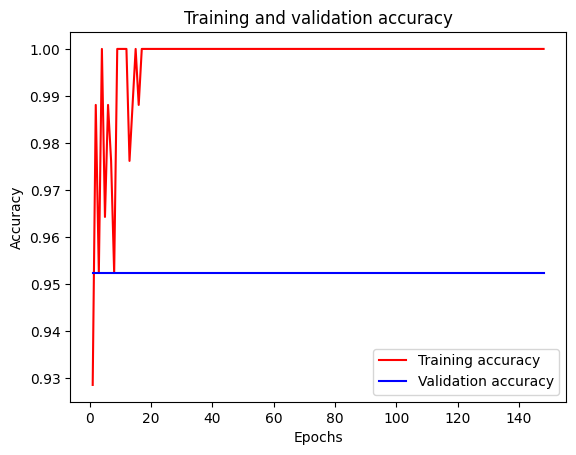

In [19]:
# learning curve
import matplotlib.pyplot as plt

# accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "r" is for "solid red line"
plt.plot(epochs, acc, 'r', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

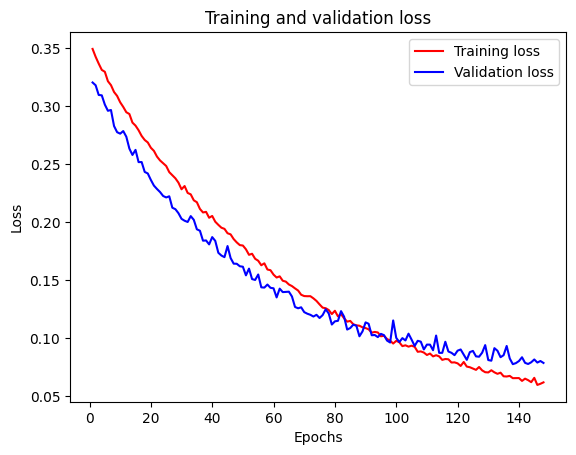

In [20]:
# learning curve
import matplotlib.pyplot as plt

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "r" is for "solid red line"
plt.plot(epochs, loss, 'r', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# see how the model did - ON DATA IT HAS NEVER SEEN!
preds = model.predict(X_test)
print(preds.shape)

# i'm spreading that prediction across three nodes and they sum to 1
print(preds[0])

# sum it up! see how probability mass (1) is spread over three preds?
np.sum(preds[0])

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


(45, 3)
[9.9937832e-01 6.2165258e-04 1.9528629e-11]


np.float32(1.0)

In [22]:
# here is y_test - still one-hot encoded
y_test

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [23]:
# here is what argmax does
y_test.argmax(axis=1)

array([0, 0, 2, 0, 1, 1, 2, 1, 0, 1, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2, 0, 2,
       0, 0, 2, 1, 0, 1, 1, 0, 1, 2, 0, 2, 2, 2, 1, 0, 2, 0, 2, 1, 0, 0,
       1])

In [24]:
preds

array([[9.99378324e-01, 6.21652580e-04, 1.95286287e-11],
       [9.99532461e-01, 4.67613718e-04, 6.67891523e-12],
       [5.09577376e-07, 4.66187894e-02, 9.53380704e-01],
       [9.99866128e-01, 1.33856069e-04, 8.35568919e-13],
       [3.43342472e-05, 6.79906428e-01, 3.20059240e-01],
       [1.81422060e-04, 9.44916189e-01, 5.49023747e-02],
       [1.68087251e-08, 8.65645241e-03, 9.91343498e-01],
       [5.85884118e-05, 4.77367222e-01, 5.22574246e-01],
       [9.99899149e-01, 1.00874997e-04, 1.49343482e-13],
       [3.67980010e-06, 1.57211751e-01, 8.42784524e-01],
       [7.42490442e-08, 3.08728814e-02, 9.69126999e-01],
       [1.46328282e-04, 8.95829678e-01, 1.04024053e-01],
       [5.06261596e-04, 9.87048924e-01, 1.24448091e-02],
       [4.40626667e-04, 9.80142117e-01, 1.94172636e-02],
       [2.45174533e-06, 1.27071187e-01, 8.72926295e-01],
       [2.18934380e-03, 9.92293000e-01, 5.51766437e-03],
       [2.33133524e-05, 4.62475926e-01, 5.37500739e-01],
       [3.36649486e-09, 5.76831

In [25]:
preds.argmax(axis=1)

array([0, 0, 2, 0, 1, 1, 2, 2, 0, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2, 2, 0, 2,
       0, 0, 2, 1, 0, 1, 1, 0, 1, 2, 0, 2, 2, 2, 1, 0, 2, 0, 2, 1, 0, 0,
       1])

In [26]:
# here it is! almost a perfect prediction
# actual is left, predicted is top
# names can be found by inspecting Y
matrix = confusion_matrix(y_test.argmax(axis=1), preds.argmax(axis=1))
matrix

array([[14,  0,  0],
       [ 0, 13,  3],
       [ 0,  0, 15]])

In [27]:
# more detail on how well things were predicted
print(classification_report(y_test.argmax(axis=1), preds.argmax(axis=1)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.81      0.90        16
           2       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.94      0.94        45
weighted avg       0.94      0.93      0.93        45


# On Your Own
Like I say at the end of the video - your job as a data scientist is to help people believe in your model. You need to make sure folks don't doubt your work!

This notebook now does it the RIGHT way: we fit on `X_train` (with a val_split of 0.2 carved out of the training partition as a feedback signal), and the confusion matrix + classification report are computed on `X_test` - rows the model has NEVER seen. This is the way to do it for any type of DL project!

Now push it further:
* Change `test_size` to 0.5 and re-run. With only 75 training rows, does the model still nail the test set?
* Add `stratify=encoded_Y` to the split so each partition gets the same class mix - then check `y_test.argmax(axis=1)` counts to prove it.
* Change the `random_state` and re-run a few times. How much do your test metrics wiggle? (That wiggle is exactly why k-fold cross-validation exists... more on that soon!)

# Other key take-aways
* Note that you had to use a LabelEncoder() here and that it sorted the categories in alphabetical order and then encoded them inplace with 0, 1, 2
* You had to make dummy variables for Y (and you didn't need to do this for binary classification problems - this is because in binary classification you had 2 categories and one output node with a SIGMOID activation function which made predictions between 0 and 1).
* The output node of your neural network had 3 nodes - why? Because you have three types of flowers that you are trying to predict. Note that you are using a softmax instead of a sigmoid activation function.
  * You also are using `categorical_crossentropy` to split the predicted probability mass among your N categories.